# 单元1作业
    刘易昊 52402191055
## 问题1：Python可视化基础

In [ ]:
# 加载一些常用软件包
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels .api as sm 
import statsmodels.formula.api as smf
#加载本次作业所需的数据库
data=sns.load_dataset("mpg")
#图的基础设置，设置基础风格和画布大小
sns.set_style("whitegrid")
sns.set(rc={"figure.figsize":(10, 5)})
#中文显示设置
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei"]  

### 1.折线图

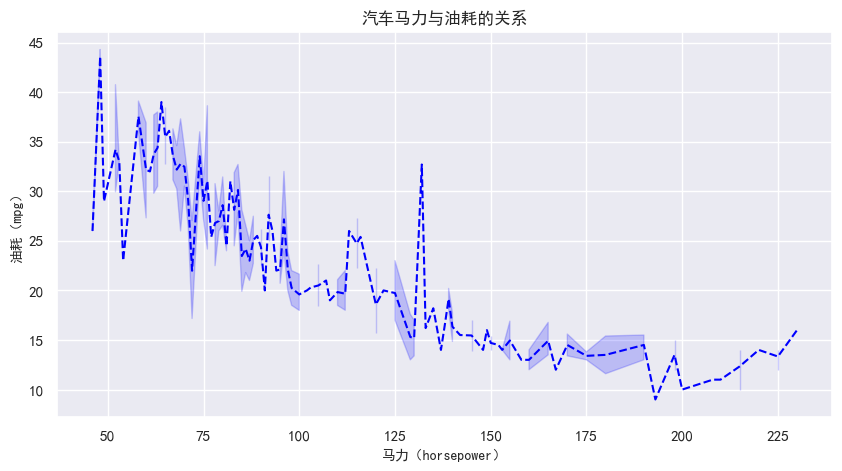

In [5]:
#通过linestyle参数设置线条样式，通过color参数设置颜色
sns.lineplot(x="horsepower",y="mpg",data=data, linestyle="--",color="blue")
#标题、坐标轴标注
plt.title("汽车马力与油耗的关系",fontsize=12)
plt.xlabel("马力（horsepower）",fontsize=10)
plt.ylabel("油耗（mpg）",fontsize=10)
plt.show()


### 2.散点图

Text(0, 0.5, '油耗（mpg）')

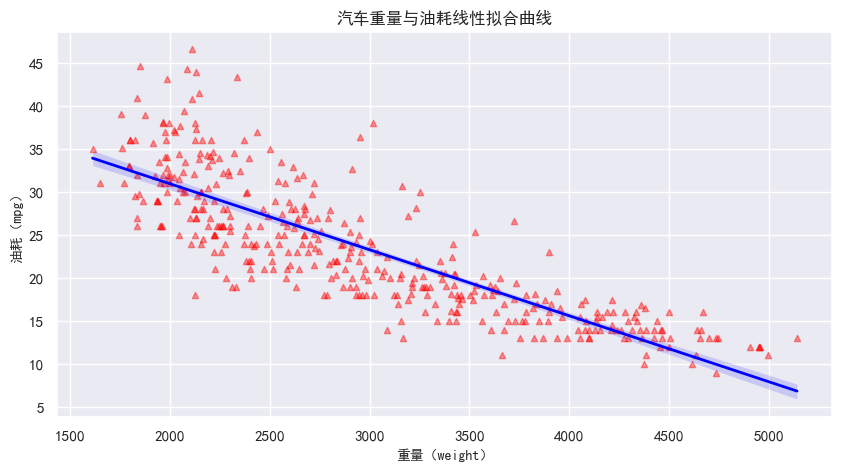

In [6]:
#通过kwx参数来分别设置散点和拟合曲线的样式
sns.regplot(x="weight", y="mpg", data=data, 
    marker='^', 
    scatter_kws={"color": "red", "s": 20,"alpha":0.4}, 
    line_kws={"color": "blue", "lw": 2})
plt.title("汽车重量与油耗线性拟合曲线",fontsize=12)
plt.xlabel("重量（weight）",fontsize=10)
plt.ylabel("油耗（mpg）",fontsize=10)

### 3.箱型图

Text(0, 0.5, '油耗（mpg）')

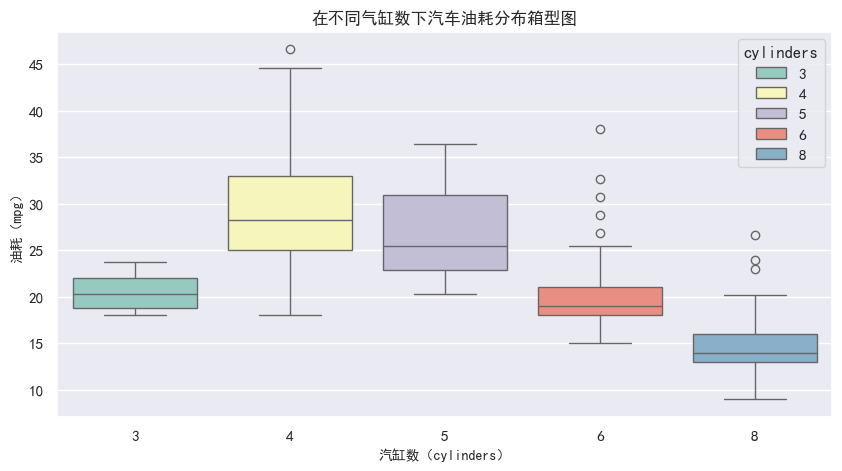

In [7]:
#通过hue和palette参数来设置不同箱型图的颜色，这里的Set3是已经搭配好的颜色组
# showfliers参数来显示异常值
sns.boxplot(x="cylinders",y="mpg",data=data,hue="cylinders",palette="Set3",showfliers=True)
plt.title("在不同气缸数下汽车油耗分布箱型图",fontsize=12)
plt.xlabel("汽缸数（cylinders）",fontsize=10)
plt.ylabel("油耗（mpg）",fontsize=10)

### 4.柱状图

Text(0, 0.5, '马力（horsepower）')

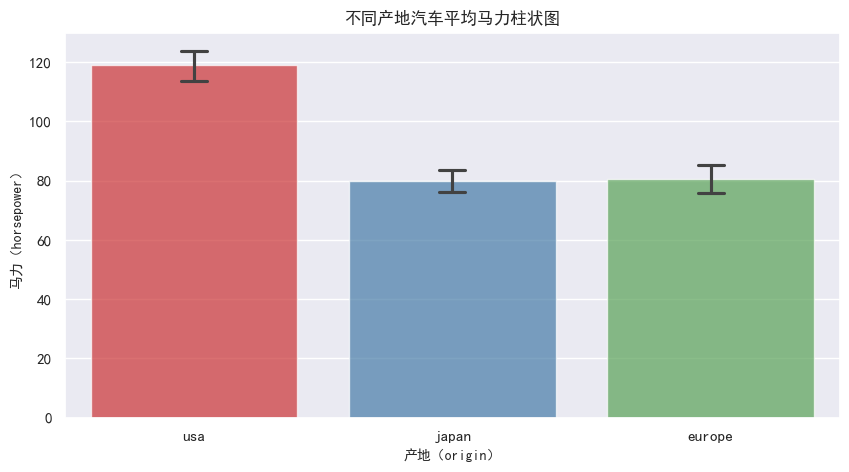

In [8]:
#由于Set1的颜色比较深，所以这里用alpha参数来设置颜色的可见度
# capaize参数来设置误差棒两端短线的长度
sns.barplot(x="origin",y="horsepower",data=data,hue="origin",palette="Set1",alpha=0.7,capsize=0.1)
plt.title("不同产地汽车平均马力柱状图",fontsize=12)
plt.xlabel("产地（origin）",fontsize=10)
plt.ylabel("马力（horsepower）",fontsize=10)

### 5.直方图

Text(0, 0.5, '频数')

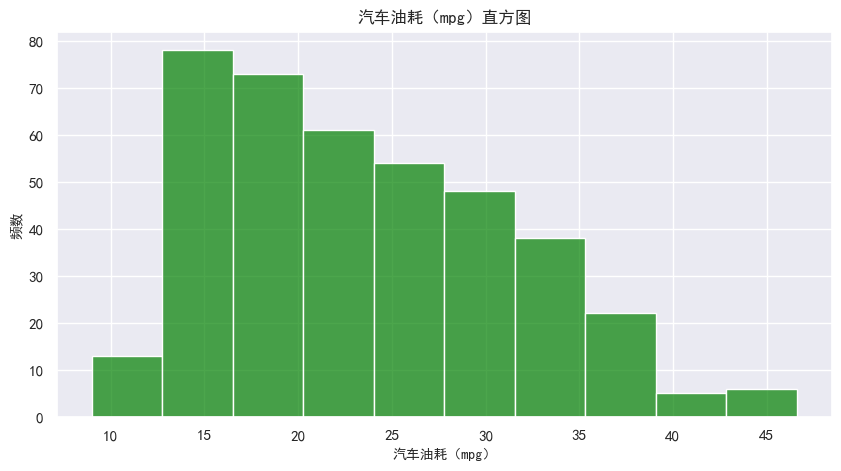

In [9]:
#通过bins参数设定分组数
sns.histplot(data=data, x="mpg",bins=10,color="green",alpha=0.7)
plt.title("汽车油耗（mpg）直方图",fontsize=12)
plt.xlabel("汽车油耗（mpg）",fontsize=10)
plt.ylabel("频数",fontsize=10)

### 6.核密度估计图

Text(0, 0.5, '概率密度')

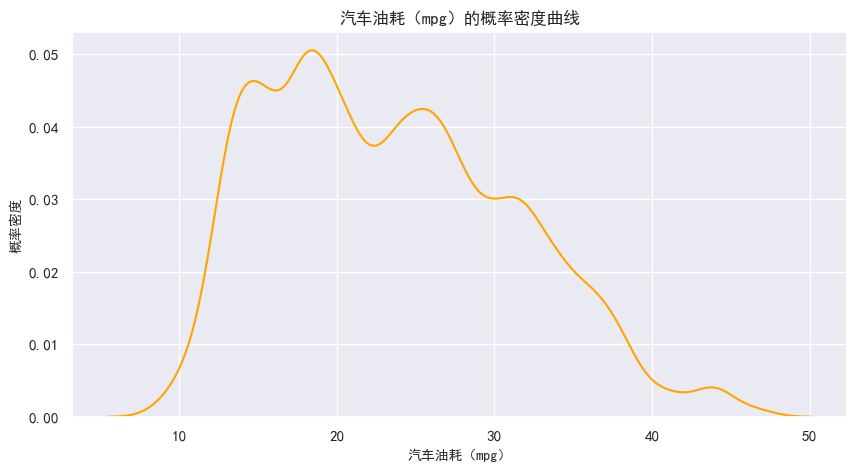

In [10]:
#通过bw_adjust参数来设置带宽调整
sns.kdeplot(data=data,x="mpg",bw_adjust=0.5,color="orange")
plt.title("汽车油耗（mpg）的概率密度曲线",fontsize=12)
plt.xlabel("汽车油耗（mpg）",fontsize=10)
plt.ylabel("概率密度",fontsize=10)


### 7.热力图

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5]),
 [Text(0, 0.5, 'mpg'),
  Text(0, 1.5, 'cylinders'),
  Text(0, 2.5, 'displacement'),
  Text(0, 3.5, 'horsepower'),
  Text(0, 4.5, 'weight'),
  Text(0, 5.5, 'acceleration'),
  Text(0, 6.5, 'model_year')])

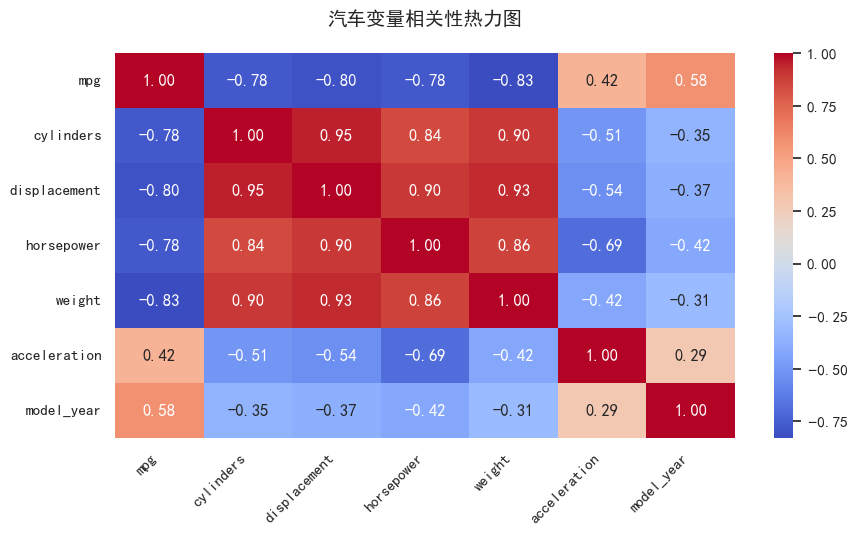

In [11]:
#用data.corr来计算相关系数，通过numeric_only来筛选数据集中参数
#用cmap参数设置颜色映射为coolwarm
#用annot参数控制相关系数的显示，tmt参数可以保留数据到两位小数
sns.heatmap(data.corr(numeric_only=True),cmap="coolwarm",annot=True,fmt=".2f")
plt.title("汽车变量相关性热力图", fontsize=14, pad=20)
#x轴文字右旋转45度，避免重叠
plt.xticks(rotation=45, ha="right")  
#y轴文字不旋转（默认旋转）
plt.yticks(rotation=0) 

### 8.联合分布图

Text(33.375, 0.5, '油耗（mpg）')

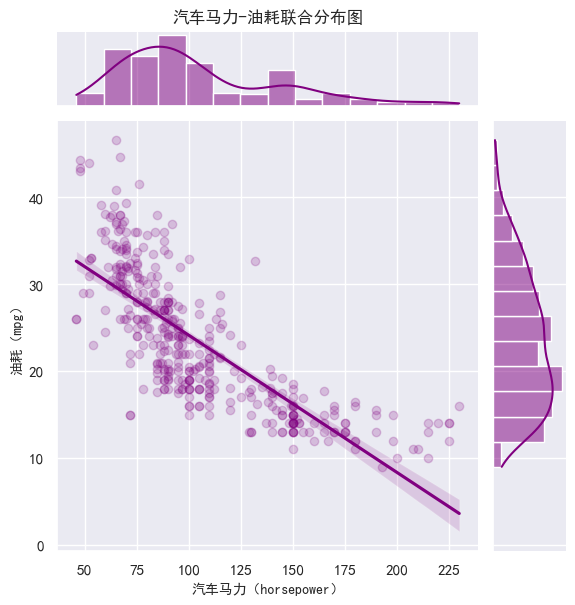

In [12]:
#用kind参数来展示回归关系
#用scatter_kws参数来设置散点的可见度，避免颜色太深看不清楚
sns.jointplot(data=data,x="horsepower",y="mpg",kind="reg",color="purple",scatter_kws={"alpha": 0.2})
#用pad参数来控制标题的生成位置
plt.title("汽车马力-油耗联合分布图",fontsize=12,pad=70)
plt.xlabel("汽车马力（horsepower）",fontsize=10)
plt.ylabel("油耗（mpg）",fontsize=10)

### 9.线性回归图

Text(0, 0.5, '油耗（mpg）')

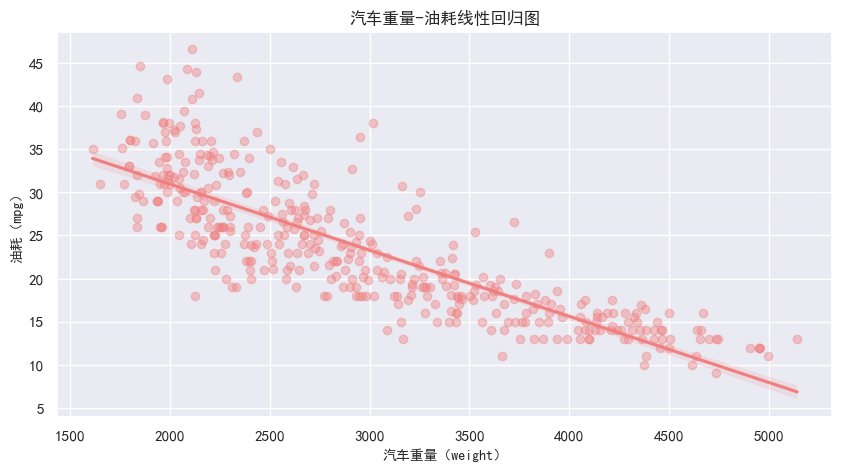

In [13]:
sns.regplot(data=data,x="weight",y="mpg",color="lightcoral",scatter_kws={"alpha": 0.4})
plt.title("汽车重量-油耗线性回归图",fontsize=12)
plt.xlabel("汽车重量（weight）",fontsize=10)
plt.ylabel("油耗（mpg）",fontsize=10)

## 问题2：Python常用函数
### 1.概率密度函数PDF

(-4.0, 4.0)

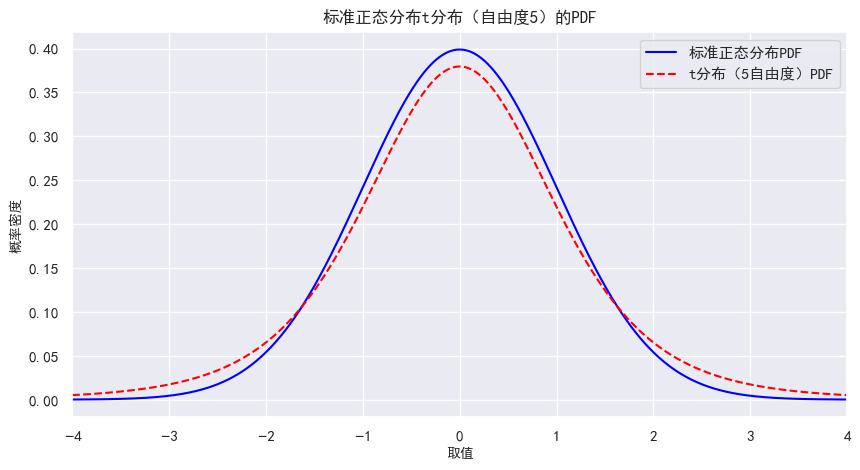

In [14]:
#设置x的左右边界为-4和4，生成1000个等间距的数值，让曲线平滑
x=np.linspace(start=-4,stop=4,num=1000)
y1=stats.norm.pdf(x,loc=0,scale=1)
y2=stats.t.pdf(x,df=5)
plt.plot(x,y1,color="blue",ls="-",label="标准正态分布PDF")
plt.plot(x,y2,color="red",ls="--",label="t分布（5自由度）PDF")
#生成图例，位置在右上方
plt.legend(loc='upper right')
plt.title('标准正态分布t分布（自由度5）的PDF', fontsize=12)
plt.xlabel('取值', fontsize=10)
plt.ylabel('概率密度', fontsize=10)
#设置x轴的显示范围
plt.xlim(-4, 4) 

### 2.随机样本生成

(-4.0, 4.0)

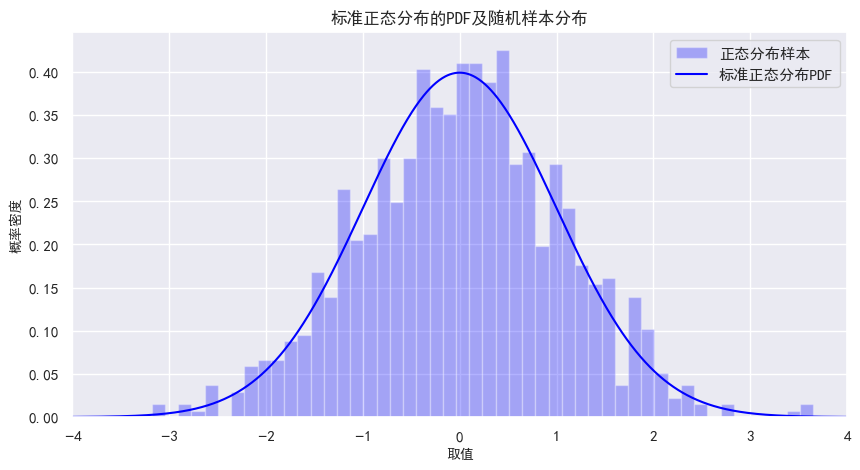

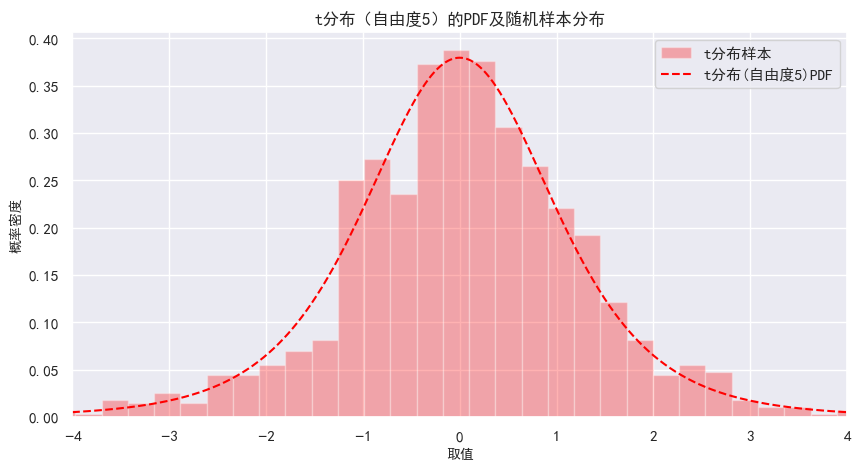

In [15]:
x=np.linspace(start=-4,stop=4,num=1000)
y1=stats.norm.pdf(x,loc=0,scale=1)
z1=stats.norm.rvs(loc=0,scale=1,size=1000)
y2=stats.t.pdf(x,df=5)
z2=stats.t.rvs(df=5,size=1000)
#用density参数来归一化直方图，让其面积之和为1
plt.hist(z1, bins=50, density=True, alpha=0.3, color="blue", label='正态分布样本')
plt.plot(x, y1, color="blue", ls="-", label='标准正态分布PDF')
plt.title('标准正态分布的PDF及随机样本分布', fontsize=12)
plt.xlabel('取值', fontsize=10)
plt.ylabel('概率密度', fontsize=10)
plt.legend(loc='upper right') 
plt.xlim(-4, 4) 
#设置新的画布避免两张图片重叠
plt.figure(figsize=(10, 5)) 
plt.hist(z2, bins=50, density=True, alpha=0.3, color="red", label='t分布样本')
plt.plot(x, y2, color="red", ls="--", label='t分布(自由度5)PDF')
plt.title('t分布（自由度5）的PDF及随机样本分布', fontsize=12)
plt.xlabel('取值', fontsize=10)
plt.ylabel('概率密度', fontsize=10)
plt.legend(loc='upper right')
plt.xlim(-4, 4) 

### 3.计算累积分布函数（CDF）与生存函数（SF）
对于某个特定值，此处选择x=1.25
- 计算正态分布和t分布在该点的累积分布函数（CDF）

In [16]:
x=1.25
cdf1=stats.norm.cdf(x,loc=0,scale=1)
cdf2=stats.t.cdf(x,df=5)
#用round函数保留两位小数
print("正态分布在x=1.25处的累积分布函数等于",round(cdf1,2)) 
print("t分布在x=1.25处的累积分布函数等于",round(cdf2,2)) 

正态分布在x=1.25处的累积分布函数等于 0.89
t分布在x=1.25处的累积分布函数等于 0.87


- 计算生存函数（SF）

In [17]:
x=1.25
sf1=stats.norm.sf(x,loc=0,scale=1)
sf2=stats.t.sf(x,df=5)
print("正态分布在x=1.25处的生存函数等于",round(sf1,2)) 
print("t分布在x=1.25处的生存函数等于",round(sf2,2)) 

正态分布在x=1.25处的生存函数等于 0.11
t分布在x=1.25处的生存函数等于 0.13


- 解释CDF和SF的含义

    CDF计算的是 $\int_{-\infty}^{x_0} f_X(x) dx$，即$ P(X \le x_0) $的值。

    SF计算的是 $\int_{x_0}^{\infty} f_X(x) dx$，即$ P(X > x_0) $的值。

    所以他们之间有SF=1-CDF的关系。

### 4.计算分位数函数

PPF 计算的是满足 $P(X \le x_p)=p$ 的 $x_p$ 的值，即 $x_p=F^{-1}(p)$ ，所以PPF是CDF的逆函数。

In [18]:
ppf1=stats.norm.ppf(0.95,loc=0,scale=1)
ppf2=stats.t.ppf(0.95,df=5)
print("正态分布的0.95分位数等于",round(ppf1,2)) 
print("t分布的0.95分位数等于",round(ppf2,2)) 

正态分布的0.95分位数等于 1.64
t分布的0.95分位数等于 2.02
